# 最小部屋数実験

方向多重集合 $(\mathcal P, m)$ に属する2次元 affine 直線配置の**最小部屋数** `minchamber(P,m)`
に関する予想を，合法手ソルバを用いて数値的に検証する。

**測定する量**: 部屋数 $\chi(A)$ (`chamber_count`)、交点重複度 $p_k$
(`intersection_multiplicities`)、飽和方向 (`saturated_directions`)、$s(A)$
(`s_invariant`/`generator_size`)、$B_2$型判定 (`is_B2_type`)、擬飽和判定
(`is_quasi_saturated`)、および閉形式 (`minchamber_n2`, `minchamber_n3`,
`yoshinaga_bound`, `saturation_chamber`, `saturation_lower_bound`)。

In [1]:
# §1  Setup: repo path + Sage-free imports of the combinatorial engine/helpers.
%matplotlib inline
import sys
from pathlib import Path
from fractions import Fraction
from itertools import product, permutations

def _find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for path in (start, *start.parents):
        if (path / "src" / "hyperplane_arrangements").is_dir():
            return path
    raise RuntimeError("Run this notebook from inside the repository.")

ROOT = _find_repo_root()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from hyperplane_arrangements.minimal_region import (
    GreedyCutAllSolver, Solution, plot_solution,
    chamber_count, intersection_multiplicities, saturated_directions,
    s_invariant, generator_size, is_B2_type, is_quasi_saturated,
    minchamber_n2, minchamber_n3, yoshinaga_bound,
    saturation_chamber, saturation_lower_bound,
)
print("loaded helpers from", ROOT)

loaded helpers from /Users/kaji/Library/CloudStorage/Dropbox/maple/HyperplaneArrangement


In [2]:
# §1  Experiment-size bounds (tune for runtime vs coverage).
BOUND_N2 = 6        # prop:n=2 sweep, per direction
BOUND_N3 = 4        # prop:n=3 sweep, per direction
QUASI_PS = [2, 3, 4]        # quasi-saturated family parameters p
GUARANTEE_BOUND = {3: 3, 4: 2, 5: 2}   # per-|P| sweep bound in the guarantee scan
CONE_CHECK_CAP = 20     # max distinct s>=4 cones to test for freeness

In [3]:
# §1  Experiment harness.
#
# NOTE: GreedyCutAllSolver merges/reorders normals, so the count-tuple order
# follows sol.normals, NOT the input order. Always match by multiset of counts
# and read directions from sol.normals. Every direction set must contain (0,1).

ALL_SOLUTIONS = []   # [(label, Solution)] accumulated across sections

def solve_all(normals, max_counts, label=None):
    results = GreedyCutAllSolver(list(normals), list(max_counts)).solve_all()
    if label is not None:
        for counts, sol in results.items():
            ALL_SOLUTIONS.append((f"{label} {counts}", sol))
    return results

def run(normals, m, label=None):
    "Minimal-chamber Solution at the full count m (matched as a multiset)."
    results = solve_all(normals, m, label=label)
    target = sorted(m)
    for counts, sol in results.items():
        if sorted(counts) == target:
            return sol
    raise ValueError(f"no full-count solution for m={m}")

def n_present(sol):
    return sum(1 for o in sol.lines_by_dir if len(o) > 0)

def total_lines(sol):
    return sum(len(o) for o in sol.lines_by_dir)

def is_concurrent(sol):
    "True if every line passes through a single common point (a pencil)."
    mult = intersection_multiplicities(sol.normals, sol.lines_by_dir)
    return total_lines(sol) >= 2 and len(mult) == 1 and list(mult) == [total_lines(sol)]

def classify(sol):
    "conjecture:guarantee tags for a Solution."
    sat = saturated_directions(sol.normals, sol.lines_by_dir)
    qs = is_quasi_saturated(sol.normals, sol.lines_by_dir)
    s = generator_size(sol)
    tags = []
    if sat: tags.append("saturated")
    if qs:  tags.append("quasi-saturated")
    if s == 3: tags.append("s=3")
    return tags, sat, qs, s

SUMMARY = {}  # section -> (n_checked, n_issues)
def record(section, n_checked, issues):
    SUMMARY[section] = (n_checked, len(issues))
    return issues

##  Zaslavsky 公式

$\chi(A)=1+|A|+\sum_{X\in L_2}(\mathrm{mult}(X)-1)$ と
ソルバの `regions` と一致するか確認

In [5]:
# §4  Zaslavsky cross-check over everything collected so far.
bad = []
for lbl, sol in ALL_SOLUTIONS:
    cc = chamber_count(sol.normals, sol.lines_by_dir)
    if cc != sol.regions:
        bad.append((lbl, sol.regions, cc))
print("Zaslavsky cross-check over", len(ALL_SOLUTIONS), "solutions; mismatches:", bad)
record("§4 Zaslavsky", len(ALL_SOLUTIONS), bad)
assert not bad

Zaslavsky cross-check over 19 solutions; mismatches: []


## 飽和配置の部屋数 $(a_\alpha+1)(N-a_\alpha+1)$

飽和可能な族について、検出された各飽和方向で部屋数公式が成り立つことを確認

In [6]:
# §5  prop:saturated-min
examples = [
    ([(1, 0), (0, 1), (1, -1), (1, -2)], [3, 2, 2, 1]),  # P1 (rem:m_not_enough)
    ([(1, 0), (0, 1)], [4, 3]),                           # 2-direction grid
    ([(1, 0), (0, 1), (1, 1), (1, -1)], [5, 1, 1, 1]),    # one dominant direction
]
issues = []
for normals, m in examples:
    sol = run(normals, m, label="sat")
    N = total_lines(sol)
    sat = saturated_directions(sol.normals, sol.lines_by_dir)
    print(normals, m, "-> regions", sol.regions,
          "saturated dirs", [sol.normals[i] for i in sat])
    for i in sat:
        a = len(sol.lines_by_dir[i])
        formula = saturation_chamber(a, N)
        ok = sol.regions == formula
        print(f"    dir {sol.normals[i]}: a={a}, (a+1)(N-a+1)={formula}  {'OK' if ok else 'FAIL'}")
        if not ok:
            issues.append((normals, m, sol.normals[i], sol.regions, formula))
record("§5 saturated-min", len(examples), issues)
assert not issues

[(1, 0), (0, 1), (1, -1), (1, -2)] [3, 2, 2, 1] -> regions 24 saturated dirs [(1, 0)]
    dir (1, 0): a=3, (a+1)(N-a+1)=24  OK
[(1, 0), (0, 1)] [4, 3] -> regions 20 saturated dirs [(1, 0), (0, 1)]
    dir (1, 0): a=4, (a+1)(N-a+1)=20  OK
    dir (0, 1): a=3, (a+1)(N-a+1)=20  OK
[(1, 0), (0, 1), (1, 1), (1, -1)] [5, 1, 1, 1] -> regions 24 saturated dirs [(1, 0)]
    dir (1, 0): a=5, (a+1)(N-a+1)=24  OK


##
同じ $m=(3,2,2,1)$ でも $\mathcal P_1$ は飽和可能（$\chi=24$）、
$\mathcal P_2$ は不可能（$\chi=25$）。検出された飽和方向で
$a_\alpha \ge (N-n+2)/2$ を確認。

In [8]:
# §6  corollary:houwa_lowerbound + rem:m_not_enough
cases = [
    ([(1, 0), (0, 1), (1, -1), (1, -2)], [3, 2, 2, 1], "P1 (saturable)"),
    ([(1, 0), (0, 1), (1, -1), (3, -1)], [3, 2, 2, 1], "P2 (not saturable)"),
]
issues = []
for normals, m, label in cases:
    sol = run(normals, m, label="lb")
    sat = saturated_directions(sol.normals, sol.lines_by_dir)
    N, n = total_lines(sol), len(sol.normals)
    lb = saturation_lower_bound(N, n)
    print(f"{label}: regions={sol.regions}, saturated dirs={[sol.normals[i] for i in sat]}, lower bound (N-n+2)/2={lb}")
    for i in sat:
        a = len(sol.lines_by_dir[i])
        ok = lb <= a
        print(f"    a({sol.normals[i]})={a}  >= {lb}?  {'OK' if ok else 'FAIL'}")
        if not ok:
            issues.append((label, a, lb))
record("§6 houwa_lowerbound", len(cases), issues)
assert not issues

P1 (saturable): regions=24, saturated dirs=[(1, 0)], lower bound (N-n+2)/2=3
    a((1, 0))=3  >= 3?  OK
P2 (not saturable): regions=25, saturated dirs=[], lower bound (N-n+2)/2=3


## 擬飽和

$B_2$型・$m=(2p,2p,1,1)$ ($p\ge2$) の最小配置は擬飽和で
$\chi=(2p+2)^2$、交点プロフィール $(p_2,p_3,p_4)=(4(p^2-p+1),4p-3,1)$

In [7]:
# §9  quasi-saturated family
issues = []
for p in QUASI_PS:
    a = 2 * p
    sol = run([(1, 0), (0, 1), (1, 1), (1, -1)], [a, a, 1, 1], label="quasi")
    mult = intersection_multiplicities(sol.normals, sol.lines_by_dir)
    qs = is_quasi_saturated(sol.normals, sol.lines_by_dir)
    expected_mult = {2: 4 * (p * p - p + 1), 3: 4 * p - 3, 4: 1}
    chamber = (2 * p + 2) ** 2
    print(f"p={p} m=({a},{a},1,1): regions={sol.regions} (exp {chamber}), "
          f"mult={mult} (exp {expected_mult}), is_quasi_saturated={qs}")
    if sol.regions != chamber:
        issues.append(("chamber", p, sol.regions, chamber))
    if mult != expected_mult or not qs:
        issues.append(("fingerprint", p, mult, qs))
record("§9 quasi-saturated", len(QUASI_PS), issues)
assert not issues

p=2 m=(4,4,1,1): regions=36 (exp 36), mult={2: 12, 3: 5, 4: 1} (exp {2: 12, 3: 5, 4: 1}), is_quasi_saturated=True
p=3 m=(6,6,1,1): regions=64 (exp 64), mult={2: 28, 3: 9, 4: 1} (exp {2: 28, 3: 9, 4: 1}), is_quasi_saturated=True
p=4 m=(8,8,1,1): regions=100 (exp 100), mult={2: 52, 3: 13, 4: 1} (exp {2: 52, 3: 13, 4: 1}), is_quasi_saturated=True


## $N-3 > \sum_{k\ge3}(k-2)p_k \;\Rightarrow\; s(A)\ge4$の確認

In [13]:
# §11  prop:cutoff-counting (one-way)
viol = []
n_pred = 0
for lbl, sol in ALL_SOLUTIONS:
    N = total_lines(sol)
    if N < 4:
        continue
    mult = intersection_multiplicities(sol.normals, sol.lines_by_dir)
    rhs = sum((k - 2) * pk for k, pk in mult.items() if k >= 3)
    s = generator_size(sol)
    if N - 3 > rhs:
        n_pred += 1
        if s < 4:
            viol.append((lbl, N, rhs, s))
print(f"prop:cutoff-counting: {n_pred} configs trigger the s>=4 prediction; violations:", viol)
record("§11 cutoff-counting", n_pred, viol)
assert not viol

prop:cutoff-counting: 49 configs trigger the s>=4 prediction; violations: []


## 予想

「任意の $(\mathcal P,m)$ の**最小配置**は (1) 飽和、(2) 擬飽和、(3) $s(A)=3$ の
いずれかを満たす」の反例を探索


In [15]:
# §13  conjecture:guarantee (headline) -- report counterexample candidates.
DIRSETS = {
    "n=3 generic":   [(1, 0), (0, 1), (1, 1)],
    "B2":            [(1, 0), (0, 1), (1, 1), (1, -1)],
    "n=4 generic":   [(1, 0), (0, 1), (1, 2), (2, 1)],
    "n=4 generic-2": [(1, 0), (0, 1), (1, 1), (1, 3)],
    "n=5":           [(1, 0), (0, 1), (1, 1), (1, -1), (1, 2)],
}
counterexamples = []
n_scanned = 0
for name, P in DIRSETS.items():
    n = len(P)
    bound = GUARANTEE_BOUND.get(n, 2)
    results = solve_all(P, [bound] * n, label=f"guar:{name}")
    print(f"  {name:14s} B2={is_B2_type(P)!s:5s} bound={bound}  ({len(results)} count-vectors)")
    for counts, sol in results.items():
        if any(c == 0 for c in counts) or sum(counts) < n:
            continue
        n_scanned += 1
        tags, sat, qs, s = classify(sol)
        if not tags:
            counterexamples.append((name, counts, sol.regions, s,
                                    [sol.normals[i] for i in sat], qs))
# Curated larger (P,m) (kept fast by avoiding many simultaneously high counts).
CURATED = [
    ([(1, 0), (0, 1), (1, 1), (1, -1)], [3, 2, 2, 1]),
    ([(1, 0), (0, 1), (1, 1), (1, -1)], [3, 3, 2, 2]),
    ([(1, 0), (0, 1), (1, 1), (1, -1)], [4, 3, 2, 1]),
    ([(1, 0), (0, 1), (1, 1), (1, -1)], [4, 4, 1, 1]),  # quasi-saturated
    ([(1, 0), (0, 1), (1, 2), (2, 1)], [3, 2, 2, 1]),
    ([(1, 0), (0, 1), (1, 2), (2, 1)], [2, 2, 2, 1]),
    ([(1, 0), (0, 1), (1, 1), (1, 3)], [3, 2, 2, 1]),
]
for P, m in CURATED:
    sol = run(P, m, label="guar:curated")
    n_scanned += 1
    tags, sat, qs, s = classify(sol)
    if not tags:
        counterexamples.append(("curated", tuple(len(o) for o in sol.lines_by_dir),
                                sol.regions, s, [sol.normals[i] for i in sat], qs))

print(f"\nconjecture:guarantee: scanned {n_scanned} minimal configs (>=n directions)")
print(f"candidate counterexamples (none of saturated / quasi-saturated / s=3): {len(counterexamples)}")
for c in counterexamples:
    print("   ", c)
record("§13 guarantee", n_scanned, counterexamples)

  n=3 generic    B2=False bound=3  (31 count-vectors)
  B2             B2=True  bound=2  (31 count-vectors)
  n=4 generic    B2=False bound=2  (31 count-vectors)
  n=4 generic-2  B2=False bound=2  (31 count-vectors)


  n=5            B2=False bound=2  (63 count-vectors)



conjecture:guarantee: scanned 111 minimal configs (>=n directions)
candidate counterexamples (none of saturated / quasi-saturated / s=3): 0


[]

## §14  `conjecture:1`（旧予想）について

「最小配置は $s(A)$ を最小化する」。これは固定 $(\mathcal P,m)$ 内の**全配置**の
$s$ 値が必要だが、本ソルバは各 count ベクトルにつき最小部屋数の配置のみ保持し
他の配置を捨てるため、現状では直接検証できない（`remark:1` の通り飽和では成り立たない）。
代替として、最小配置たちの $s$ 値の分布を参考として示す。

In [16]:
# §14  conjecture:1 -- documented limitation; show s-distribution of minimal configs.
from collections import Counter
s_dist = Counter(generator_size(sol) for _, sol in ALL_SOLUTIONS
                 if total_lines(sol) >= 3 and n_present(sol) >= 3)
print("s(A) distribution among collected minimal-chamber configs (n>=3):")
for s in sorted(s_dist):
    print(f"    s={s}: {s_dist[s]}")
print("Note: a full test of conjecture:1 needs enumeration of ALL configurations per (P,m),")
print("which the greedy solver does not retain (it keeps only the best per count vector).")

s(A) distribution among collected minimal-chamber configs (n>=3):
    s=2: 119
    s=3: 332
    s=4: 90
    s=5: 10
    s=6: 6
Note: a full test of conjecture:1 needs enumeration of ALL configurations per (P,m),
which the greedy solver does not retain (it keeps only the best per count vector).


## 予想：$s(A)\ge4$ ならば、最小配置の錐 $\hat A=cA$ は divisionally free


In [17]:
# §15  conjecture:2 (requires Sage)
try:
    from hyperplane_arrangements import HyperplaneArrangement
    HAVE_SAGE = True
except Exception as e:
    HAVE_SAGE = False
    print("Sage unavailable -> skipping conjecture:2 freeness check:", e)

if HAVE_SAGE:
    seen, nonfree = set(), []
    checked = 0
    for lbl, sol in ALL_SOLUTIONS:
        if generator_size(sol) < 4:
            continue
        key = (sol.normals, sol.lines_by_dir)
        if key in seen:
            continue
        seen.add(key)
        if checked >= CONE_CHECK_CAP:
            break
        cone = HyperplaneArrangement.cone_of_lines(sol.normals, sol.lines_by_dir)
        free = bool(cone.is_free)
        checked += 1
        if not free:
            nonfree.append((lbl, generator_size(sol), sol.regions, cone.degrees()))
    print(f"conjecture:2: checked {checked} distinct s>=4 configs; non-free cones: {nonfree}")
    record("§15 conjecture:2", checked, nonfree)

conjecture:2: checked 20 distinct s>=4 configs; non-free cones: []


## 付録: 配置の可視化

任意の `Solution` を `plot_solution` で描画できる。

regions = 36  s(A) = 4  quasi-saturated = True


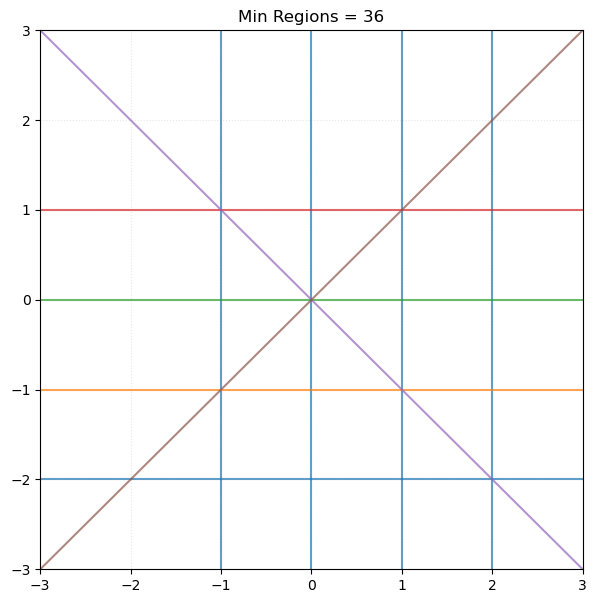

In [20]:
# Visualise one of the B2 quasi-saturated minimal configurations.
sol = run([(1, 0), (0, 1), (1, 1), (1, -1)], [4, 4, 1, 1])
print("regions =", sol.regions, " s(A) =", generator_size(sol),
      " quasi-saturated =", is_quasi_saturated(sol.normals, sol.lines_by_dir))
plot_solution(sol)